In [1]:
import numpy as np
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [66]:
class FullSMO:
    def __init__(self, X, y, C, tol, max_iter,random_state=42):
        self.X = X
        self.y = y
        self.C = C
        self.tol = tol
        self.m, self.n = X.shape
        rgen = np.random.RandomState(random_state)
        self.all_lambdas=rgen.uniform(0,C,size=self.m)   # 產生m筆樣本的初始lambda
        # self.all_lambdas=np.zeros(self.m)
        self.b = 0
        self.errors = self._calc_all_errors()
        self.max_iter = max_iter    # 最多迭代次數

    def _calc_error(self, i):
        """計算第 i 個點的誤差 Ei = f(xi) - yi"""
        f_xi =self._f(self.X[i, :])
        return f_xi - self.y[i]

    def _calc_all_errors(self):
        """初始化或更新全局誤差緩存"""
        return np.array([self._calc_error(i) for i in range(self.m)])

    def _select_2(self, i, Ei):
        """內層循環：啟發式挑選 lambdaj，使其 |Ei - Ej| 最大"""
        max_idx = -1
        max_delta_e = 0
        Ej = 0
        
        # 尋找已經計算過的非零誤差中，差距最大的一個
        valid_error_indices = np.where((self.all_lambdas > 0) & (self.all_lambdas < self.C))[0]
        
        if len(valid_error_indices) > 1:
            for k in valid_error_indices:
                if k == i: continue
                Ek = self._calc_error(k)
                delta_e = abs(Ei - Ek)
                if delta_e > max_delta_e:
                    max_idx = k
                    max_delta_e = delta_e
                    Ej = Ek
            return max_idx, Ej
        else:
            # 如果沒有合適的非邊界點，就隨機選一個
            j = np.random.choice([x for x in range(self.m) if x != i],replace=True)   # 隨機選第二筆            
            return j, self._calc_error(j)
    def _f(self,x): # 目標函數值
        f_xi = float(np.dot((self.all_lambdas * self.y), self._kernel(x))) + self.b
        return f_xi
    def _kernel(self,x):    # 線性核(linear kernel)
        return np.dot(self.X,x.T) 
    def _update_lambda_12(self, i):
        """核心解析求解步驟"""
        E1 = self._calc_error(i)
        
        # 檢查 lambda 是否違反 KKT
        if ((self.y[i] * E1 < -self.tol and self.all_lambdas[i] < self.C) or 
            (self.y[i] * E1 > self.tol and self.all_lambdas[i] > 0)):
            
            # 1. 挑選 lambda2
            j, E2 = self._select_2(i, E1)
            lambdai_old, lambdaj_old = self.all_lambdas[i], self.all_lambdas[j]
            # alpha_i_old, alpha_j_old = self.all_lambdas[i].copy(), self.all_lambdas[j].copy()

            # 2. 計算 L 和 H
            if self.y[i] != self.y[j]:
                L = max(0, self.all_lambdas[j] - self.all_lambdas[i])
                H = min(self.C, self.C + self.all_lambdas[j] - self.all_lambdas[i])
            else:
                L = max(0, self.all_lambdas[i] + self.all_lambdas[j] - self.C)
                H = min(self.C, self.all_lambdas[i] + self.all_lambdas[j])
            if L == H: return 0

            # 3. 計算 eta
            eta = 2.0 * np.dot(self.X[i, :], self.X[j, :].T) - \
                  np.dot(self.X[i, :], self.X[i, :].T) - \
                  np.dot(self.X[j, :], self.X[j, :].T)
            if eta >= 0: return 0

            # 4. 更新 lambda2 並剪裁
            self.all_lambdas[j] -= (self.y[j] * (E1 - E2)) / eta
            self.all_lambdas[j] = np.clip(self.all_lambdas[j], L, H)
            if abs(self.all_lambdas[j] - lambdaj_old) < 1e-5: return 0

            # 5. 更新 lambda1
            self.all_lambdas[i] += self.y[i] * self.y[j] * (lambdaj_old - self.all_lambdas[j])

            # 6. 更新 b
            b1 = self.b - E1 - self.y[i]*(self.all_lambdas[i]-lambdai_old)*np.dot(self.X[i,:], self.X[i,:].T) - \
                 self.y[j]*(self.all_lambdas[j]-lambdaj_old)*np.dot(self.X[i,:], self.X[j,:].T)
            b2 = self.b - E2 - self.y[i]*(self.all_lambdas[i]-lambdai_old)*np.dot(self.X[i,:], self.X[j,:].T) - \
                 self.y[j]*(self.all_lambdas[j]-lambdaj_old)*np.dot(self.X[j,:], self.X[j,:].T)
            
            if 0 < self.all_lambdas[i] < self.C: 
                self.b = b1
            elif 0 < self.all_lambdas[j] < self.C: 
                self.b = b2
            else: self.b = (b1 + b2) / 2.0
            
            return 1
        return 0

    def fit(self):
        """外層循環：全量掃描與非邊界掃描的切換"""
        iter_count = 0    # 迭代計次
        entire_set = True # 初始遍歷所有數據點
        lambda_12_changed = 0 # 辨識尚未最終收斂
        
        while (iter_count < self.max_iter) and (lambda_12_changed > 0 or entire_set):
            lambda_12_changed = 0
            if entire_set:
                # 遍歷所有數據點
                for i in range(self.m):
                    lambda_12_changed += self._update_lambda_12(i)
                print(f"遍歷所有數據點，修改了 {lambda_12_changed} 對 lambda")
            else:
                # 僅遍歷非邊界點 (0 < alpha < C)
                non_bound_indices = np.where((self.all_lambdas > 0) & (self.all_lambdas < self.C))[0]
                for i in non_bound_indices:
                    lambda_12_changed += self._update_lambda_12(i)
                print(f"非邊界掃描，修改了 {lambda_12_changed} 對 lambda")
            
            iter_count += 1
            
            if entire_set:
                entire_set = False # 如果剛做完全量，下次切換到非邊界
            elif lambda_12_changed == 0:
                entire_set = True # 如果非邊界掃描沒東西改了，回全量掃描檢查
                
        print("訓練完成。")
    def decision_function(self,x):  # 決策函數
        return np.dot((self.all_lambdas * self.y), self._kernel(x))+ self.b 
    def predict(self, x):   # 預測函數
        f_xi = np.sign(np.dot((self.all_lambdas * self.y), self._kernel(x)) + self.b)
        return f_xi

In [67]:
iris = datasets.load_iris()
X = iris.data[:, [0, 1]]
y = iris.target
X = X[y != 2]  # 移除第3類 (維吉尼亞鳶尾)
y = y[y != 2]  # 移除第3類的標籤
y = np.where(iris.target[:100] == 0, -1, 1)
X_train, X_test, y_train, y_test = train_test_split(
     X, y, test_size=0.3, random_state=42, stratify=y)
sc = StandardScaler()
X_train_std=sc.fit_transform(X_train)
X_test_std = sc.fit_transform(X_test)
smo = FullSMO(X_train_std, y_train, C=1.0, tol=1e-3, max_iter=100,random_state=42)
smo.fit()

print(f"最終偏置 b: {smo.b}")
print(f"支撐向量數量: {np.sum(smo.all_lambdas > smo.tol)}")
np.where((smo.all_lambdas>0) & (smo.all_lambdas<=smo.C))[0]

遍歷所有數據點，修改了 53 對 lambda
非邊界掃描，修改了 13 對 lambda
非邊界掃描，修改了 6 對 lambda
非邊界掃描，修改了 1 對 lambda
非邊界掃描，修改了 0 對 lambda
遍歷所有數據點，修改了 10 對 lambda
非邊界掃描，修改了 3 對 lambda
非邊界掃描，修改了 2 對 lambda
非邊界掃描，修改了 2 對 lambda
非邊界掃描，修改了 2 對 lambda
非邊界掃描，修改了 2 對 lambda
非邊界掃描，修改了 3 對 lambda
非邊界掃描，修改了 0 對 lambda
遍歷所有數據點，修改了 1 對 lambda
非邊界掃描，修改了 0 對 lambda
遍歷所有數據點，修改了 0 對 lambda
訓練完成。
最終偏置 b: 0.11426864051239517
支撐向量數量: 10


array([ 6, 17, 22, 26, 30, 49, 52, 57, 66, 69])

In [48]:
# 繪製SVM 的決策邊界和間隔
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']  # 用於正常顯示中文標籤
plt.rcParams['axes.unicode_minus'] = False  # 用於正常顯示負號(若有負數資料)
def plot_decision_boundary(X, y, classifier, sv_indices): 
    # plt.figure(figsize=(10, 8))
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])
    # 繪製數據點(紅色、藍色區分類別)   
    plt.scatter(X[y == -1, 0], X[y == -1, 1],
                c=colors[0], marker='o', label='Class -1 (Setosa)', alpha=0.6)
    plt.scatter(X[y == 1, 0], X[y == 1, 1], 
                c=colors[1], marker='s', label='Class 1 (Versicolor)', alpha=0.6)
    
    # 標記支持向量(加黑色邊框)
    plt.scatter(X[sv_indices, 0], X[sv_indices, 1],
                s=20, linewidth=2, facecolors='none', 
                edgecolors='black',label='Support Vectors')
    
    # 繪製決策邊界
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),    #   xx.shape=(200,200) yy.shape=(200,200)
                         np.linspace(y_min, y_max, 200))
    
    # 計算網格點的決策函數值
    Z = classifier.predict(np.array([xx.ravel(), yy.ravel()]).T)    # 為每一個配對的點計算預測值
    Z = Z.reshape(xx.shape)
    Z1= classifier.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z1 = Z1.reshape(xx.shape)
    # 繪製決策邊界和間隔
    plt.contour(xx, yy, Z1, levels=[-1, 0, 1],   # 只畫等高線[-1, 0, 1]
                cmap=cmap,
                # colors=['blue', 'black', 'red'], 
                linestyles=['--', '-', '--'], 
                linewidths=[1, 2, 1])    
    plt.contourf(xx, yy, Z,
                 cmap=cmap, 
                #  colors=['lightblue', 'lightcoral'], 
                 alpha=0.3)
    
    plt.xlabel('萼片長 (已標準化)')
    plt.ylabel('萼片寬 (已標準化)')
    plt.title('SVM 決策邊界最大化')
    plt.legend()
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.grid(True, alpha=0.3)
    plt.show()

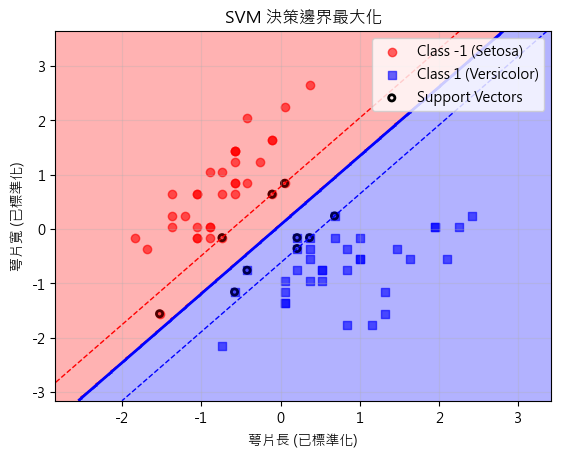

In [68]:
plot_decision_boundary(X_train_std, y_train,smo, np.where(smo.all_lambdas>0)[0])